<center><font size="5.5"><b>Wine Data Visualization for beginners 🍷 <br><br> Focus on Italy, France, Spain and Portugal</b><br></font></center><br>
<center><b>Every comment is welcome!</b></center><br>

<img src="https://www.freedonia.it/rescards/wine.jpg" width="500px"/>

In [6]:
#Import libraries
from IPython.display import display
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 

In [7]:
#Import dataset
dt = pd.read_csv("winemag-data-130k-v2.csv")
display(dt.head())
dt.shape

,Unnamed: 0,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm
3,3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,NaN,Alexander Peartree,NaN,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian
4,4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks


(129971, 14)

<font size="4"><b>Where is wine mostly produced?</b><br></font><br>
The most important wine producer in the word is the **USA**, followed by a series of **european countries** such as France, Italy and Spain and two **south american countries**, Argentina and Chile. From the graph below, we can see that the **wine market is very a concentrated market** controlled by few countries. 

C:\Anaconda\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


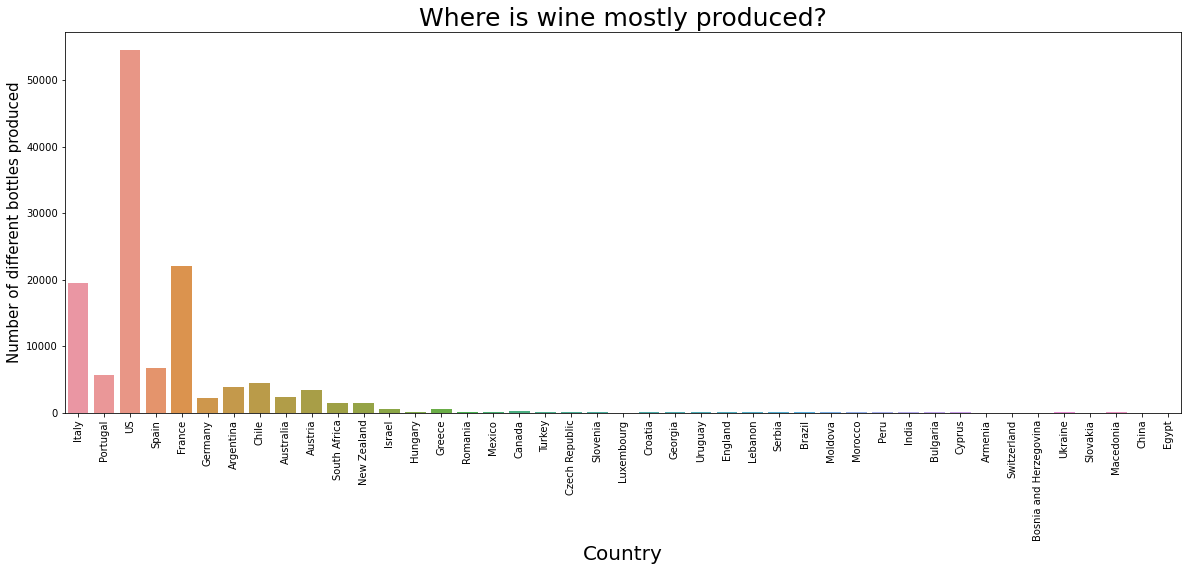

In [8]:
plt.figure(figsize=(20,7))
a = sns.countplot(dt["country"])
a.set_xlabel("Country",fontsize=20)
a.set_ylabel("Number of different bottles produced",fontsize=15)
plt.title("Where is wine mostly produced?", fontsize= 25)
plt.xticks(rotation=90)
plt.show()

<font size="5"><b><center>Focus on Europe</center></b><br></font><br>
Considering the total boottles of wine offering by the** Big Four european wine producers (France, Italy, Spain and Portugal)**, they produce approximately the same amount of types of wine compare to USA, the gratest wine producer in the world.

In [9]:
dt_eur = dt[(dt.country == "Italy") | (dt.country == "Portugal") | (dt.country == "Spain") | (dt.country == "France")]
dt_usa = dt[dt.country == "US"]

dt_eur_and_usa = pd.concat([dt_eur, dt_usa])
display(dt_eur.shape, dt_usa.shape, dt_eur_and_usa.shape)

(53969, 14)

(54504, 14)

(108473, 14)

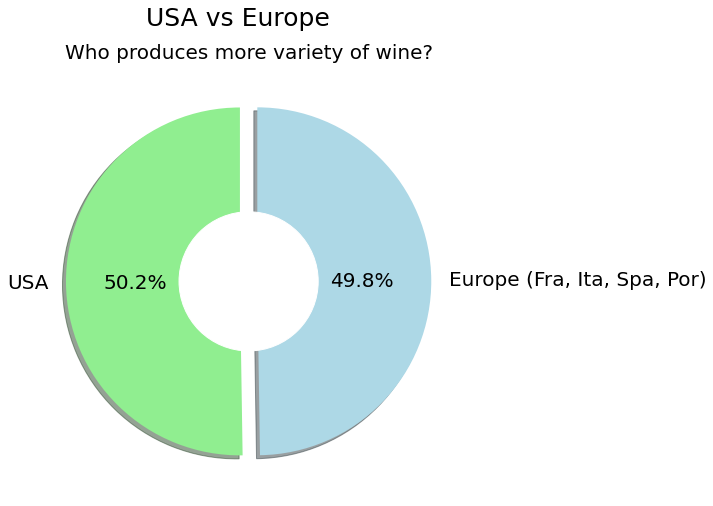

In [10]:
number_of_wine_US = dt_eur_and_usa.country[dt_eur_and_usa.country == "US"].count()
number_of_wine_eur = dt_eur_and_usa.country.count() - number_of_wine_US
explode = (0.05,0.05)
sizes = [number_of_wine_US/len(dt_eur_and_usa)*100, number_of_wine_eur/len(dt_eur_and_usa)*100]

plt.figure(figsize=(12,8))
plt.pie(sizes, labels=["USA", "Europe (Fra, Ita, Spa, Por)"],colors = ["lightgreen", "lightblue"], shadow=True, startangle=90,explode = explode, autopct='%1.1f%%', textprops={'fontsize': 20})
my_circle=plt.Circle( (0,0), 0.4, color='white')
plt.title("Who produces more variety of wine?", fontsize= 20)
plt.suptitle("USA vs Europe", fontsize= 25)
plt.gca().add_artist(my_circle)
plt.show()

In [11]:
dt_ita = dt[dt.country == "Italy"]
dt_por = dt[dt.country == "Portugal"]
dt_spa = dt[dt.country == "Spain"]
dt_fra = dt[dt.country == "France"]


display(dt_ita.shape, dt_por.shape, dt_spa.shape, dt_fra.shape, dt_eur.shape)

(19540, 14)

(5691, 14)

(6645, 14)

(22093, 14)

(53969, 14)

Looking at the Big Four wine producers in Europe, they produce 56134 types of wine. In detail, **French** and **Italy** lead the ranking with 22093 and 19540 wines respectively, followed by **Spain** (6645) and **Portugal** with 5691 different bottles.

C:\Anaconda\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


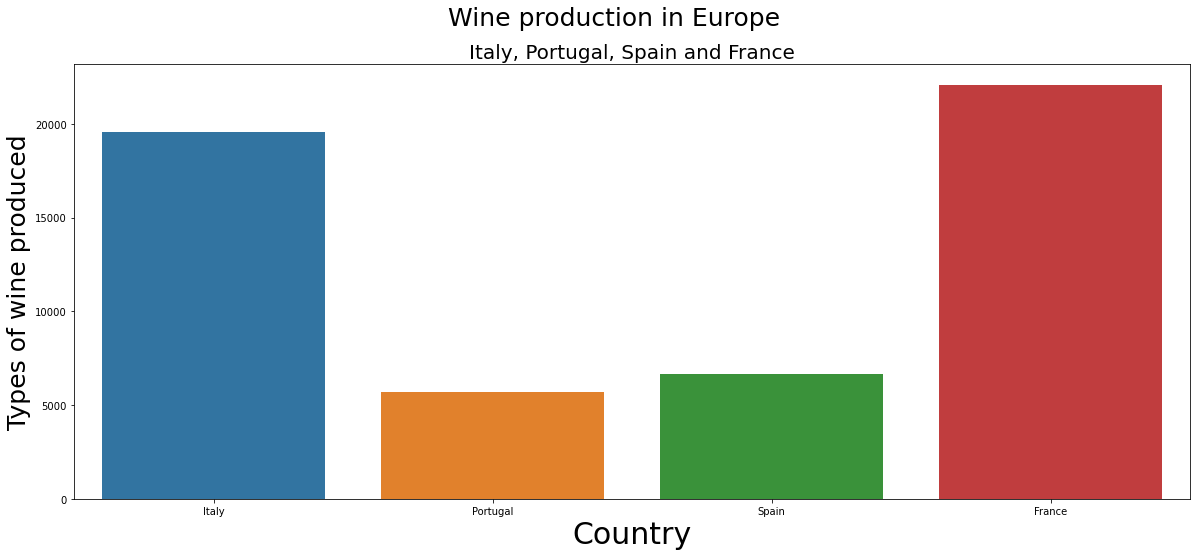

In [12]:
plt.figure(figsize=(20,8))
a = sns.countplot(dt_eur.country)
a.set_xlabel("Country",fontsize=30)
a.set_ylabel("Types of wine produced",fontsize=25)
plt.title("Italy, Portugal, Spain and France", fontsize= 20)
plt.suptitle("Wine production in Europe", fontsize= 25)
plt.show()

<font size="4"><b>Price distribution</b><br></font><br>
Looking at the price distribution among the 4 different countries, we can clearly see the **presence of outliers** (in term of price) in each country. In fact, we can easily find bottles of wine sold for few dollars up to type of wine (especially in Italy and French) which are sold for more than 2000 dollars per bottle.   

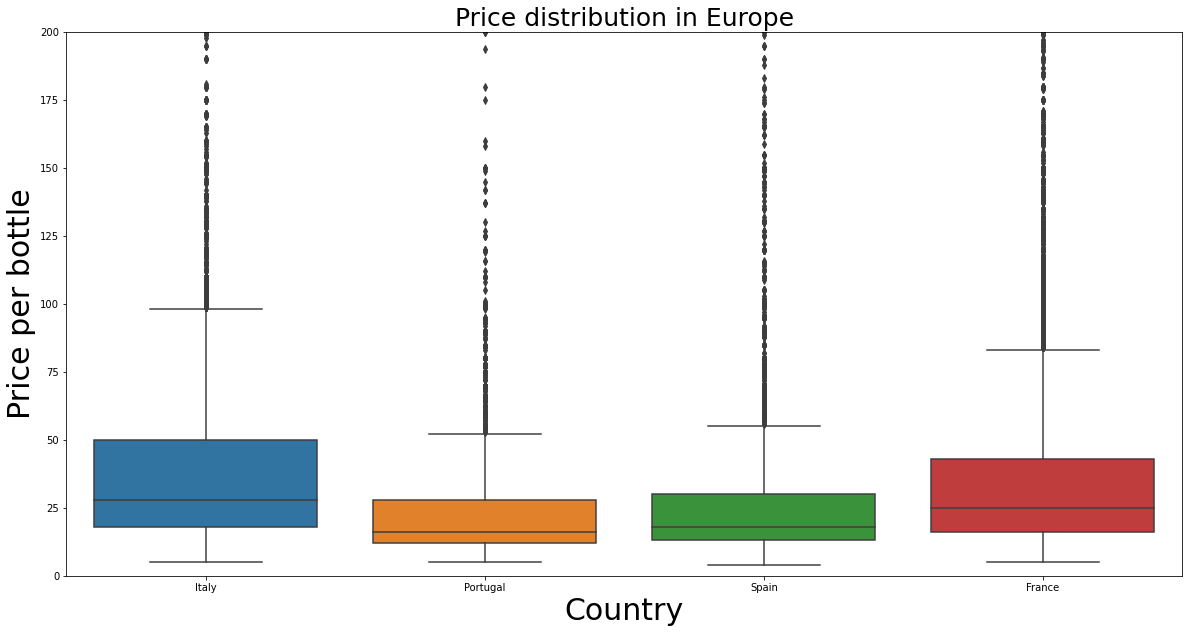

In [13]:
plt.figure(figsize=(20,10))

a = sns.boxplot(x='country', y='price', data=dt_eur)
a.set_xlabel("Country",fontsize=30)
a.set_ylabel("Price per bottle",fontsize=30)
plt.title("Price distribution in Europe", fontsize= 25)
plt.ylim(0,200)
plt.show()

<font size="4"><b>The most productive areas</b></font><br>

* **Italy**: **Tuscany**, **Piedmont** and **Veneto** are the top 3 regions in term of wine varieties.
<br>
* **Portugal**: **Douro** and **Alentejano** are the two most productive areas in Portugal. They produce about 40% of the total types of wine produced in the country. 
<br>
* **Spain**: most of the spanish wine comes from the **north of the country** (about 58% of the total).
<br>
* **France**: **Bourdeaux** and **Burgundy** are the main important french regions for wine production. **Alsace** is the third region with less than 10% of the total production.

In [14]:
dt_ita.province[dt_ita.province == "Northeastern Italy"] = "Northeastern"

C:\Users\ALEXAN~1\AppData\Local\Temp/ipykernel_9532/3602732251.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dt_ita.province[dt_ita.province == "Northeastern Italy"] = "Northeastern"
C:\Anaconda\lib\site-packages\pandas\core\generic.py:8870: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return self._update_inplace(result)


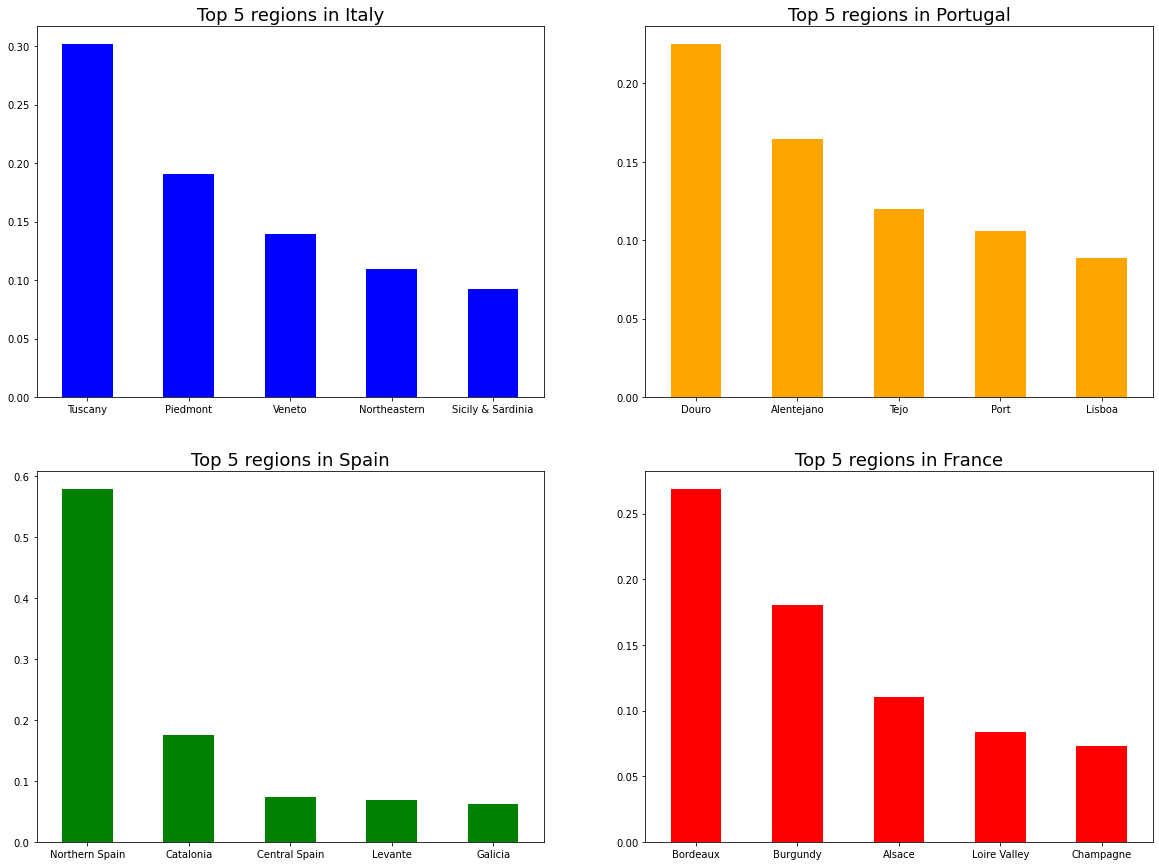

In [15]:
plt.figure(figsize=(20,15))


plt.subplot(2,2,1)
(dt_ita['province'].value_counts().head(5) / len(dt_ita)).plot.bar(color = "blue")
plt.title("Top 5 regions in Italy").set_fontsize('18')
plt.xticks(rotation=0)
plt.plot()

plt.subplot(2,2,2)
(dt_por['province'].value_counts().head(5) / len(dt_por)).plot.bar(color = "orange")
plt.title("Top 5 regions in Portugal").set_fontsize('18')
plt.xticks(rotation=0)
plt.plot()

plt.subplot(2,2,3)
(dt_spa['province'].value_counts().head(5) / len(dt_spa)).plot.bar(color = "green")
plt.title("Top 5 regions in Spain").set_fontsize('18')
plt.xticks(rotation=0)
plt.plot()

plt.subplot(2,2,4)
(dt_fra['province'].value_counts().head(5) / len(dt_fra)).plot.bar(color = "red")
plt.title("Top 5 regions in France").set_fontsize('18')
plt.xticks(rotation=0)
plt.plot()

plt.show()

<font size="4"><b>Variety per contry</b><br></font>
* **Italy**: the most popular wine in is the **Red Blend**, followed by **Nebbiolo**, produced in Piedmont, and **Sangiovese**, produced in Tuscany.
* **Portugal** : **Portuguese red** and **Portuguese white** represent more than 60% of the total portuguese wine production.
* **Spain** : in Spain, the most popular wine are the **Tempranillo**, typical of Rioja Alta and Alavesa, and the **Red Blend**.
* **France** : **Bordeaux-style red blend wine** (a wine which is blended from the Cabernet Sauvignon, Merlot, Cabernet Franc, Malbec and Petite Verdot grapesis) is the most produced wine in French followed by **Chardonnay**.

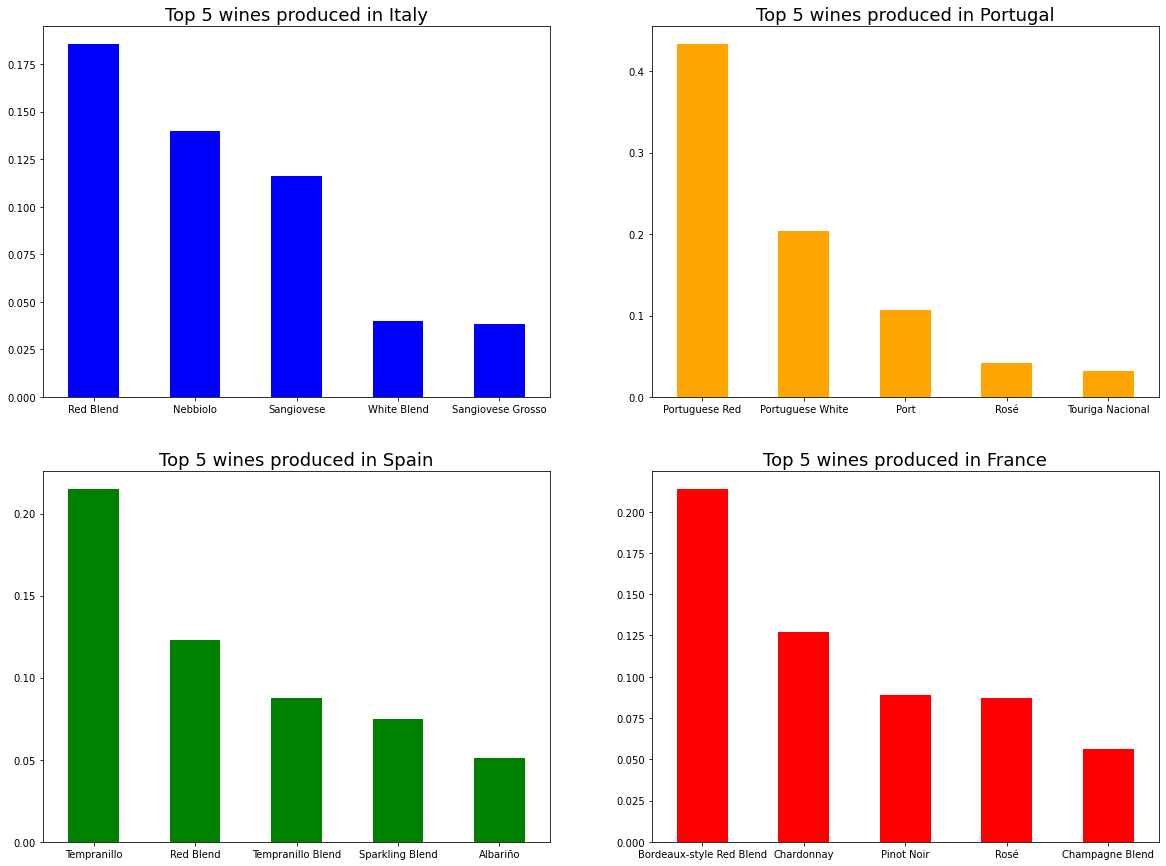

In [16]:
plt.figure(figsize=(20,15))


plt.subplot(2,2,1)
(dt_ita['variety'].value_counts().head(5) / len(dt_ita)).plot.bar(color = "blue")
plt.title("Top 5 wines produced in Italy").set_fontsize('18')
plt.xticks(rotation=0)
plt.plot()

plt.subplot(2,2,2)
(dt_por['variety'].value_counts().head(5) / len(dt_por)).plot.bar(color = "orange")
plt.title("Top 5 wines produced in Portugal").set_fontsize('18')
plt.xticks(rotation=0)
plt.plot()

plt.subplot(2,2,3)
(dt_spa['variety'].value_counts().head(5) / len(dt_spa)).plot.bar(color = "green")
plt.title("Top 5 wines produced in Spain").set_fontsize('18')
plt.xticks(rotation=0)
plt.plot()

plt.subplot(2,2,4)
(dt_fra['variety'].value_counts().head(5) / len(dt_fra)).plot.bar(color = "red")
plt.title("Top 5 wines produced in France").set_fontsize('18')
plt.xticks(rotation=0)
plt.plot()

plt.show()

<font size="4"><b>Where is the best wine?</b><br></font><br>
Looking at the average of the obtained points, we have the following ranking:
1. **France** --> 88.84 points
2. **Italy** --> 88.56 points
3. **Portugal** --> 88.25 points
4. **Spain** --> 87.28 points

In [17]:
display(dt_ita.points.mean())
display(dt_por.points.mean())
display(dt_spa.points.mean())
display(dt_fra.points.mean())

88.56223132036847

88.25021964505359

87.28833709556058

88.84510931064138

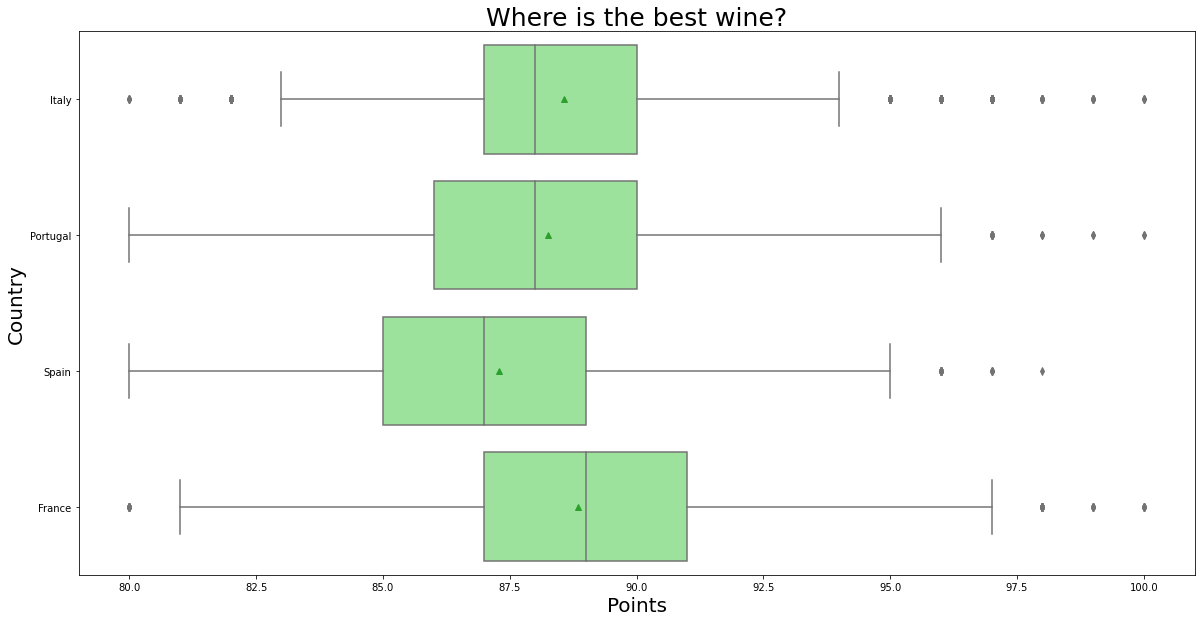

In [18]:
plt.figure(figsize=(20,10))

plt.title("Where is the best wine?", fontsize= 25)
a = sns.boxplot(x='points', y='country', data=dt_eur, showmeans=True, color = "lightgreen")
a.set_xlabel("Points",fontsize=20)
a.set_ylabel("Country",fontsize=20)
plt.show()